# **Question 18**

In [1]:
import torch
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline
from diffusers import (EulerDiscreteScheduler, EulerAncestralDiscreteScheduler, DPMSolverMultistepScheduler)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

We initialize the stable diffusion v1.5 model.

In [2]:
# model
model_id = "runwayml/stable-diffusion-v1-5"
# pipeline
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16).to("cuda")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

text_encoder/config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

safety_checker/config.json:   0%|          | 0.00/4.72k [00:00<?, ?B/s]

...

tokenizer/vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

unet/config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

vae/config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

We define the number of steps and the schedulers.

In [3]:
# steps
num_steps_list = [10, 20, 40, 80]
# schedulers
schedulers = {
    "Euler": EulerDiscreteScheduler.from_config(pipe.scheduler.config),
    "EulerAncestral": EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config),
    "DPM": DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
}

In [4]:
prompt = "a photograph of an astronaut riding a horse"

In [5]:
seed = 44

To create a grid of the generated images with the different number of steps  columns and the different schedulers as rows.

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

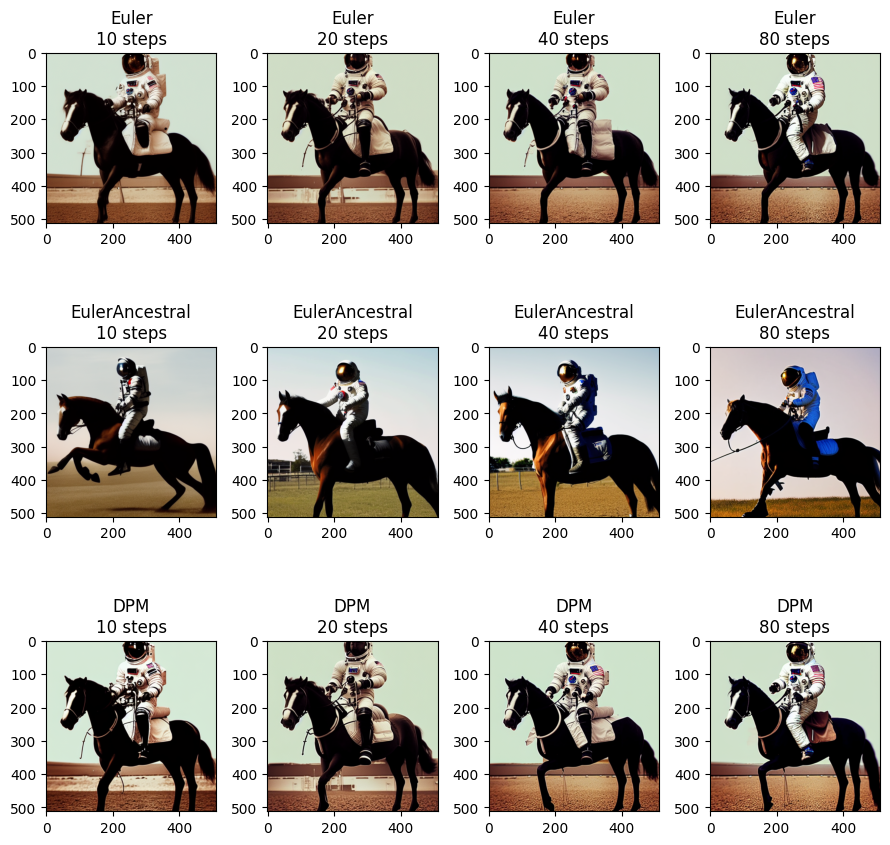

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=4, figsize=(9, 9))

for i, (name, sched) in enumerate(schedulers.items()):
  for j, steps in enumerate(num_steps_list):
    generator = torch.Generator("cuda").manual_seed(seed)
    pipe.scheduler = sched
    img = pipe(prompt=prompt, num_inference_steps=steps, generator=generator).images[0]
    ax[i][j].imshow(img)
    ax[i][j].set_title(f"{name}\n{steps} steps")

plt.tight_layout()
plt.show()

- Euler: basic/simple output.
- Euler: Ancestral: More creative and different outputs.
- DPM: A balance between the basic and creative outputs. Here, it remains a bit simple.

Euler and DPM are quite close. A difference is about the colors and one of the horse's leg generation.

Between 10 and 20 steps, the outputs across all schedulers are quite similar, with images that often lack smoothness and resolution. The details remain a bit blurry, and the overall quality is limited.

However, starting at 40 steps, there is a noticeable improvement in the image quality, with much sharper details and greater clarity.

# **Question 19**

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

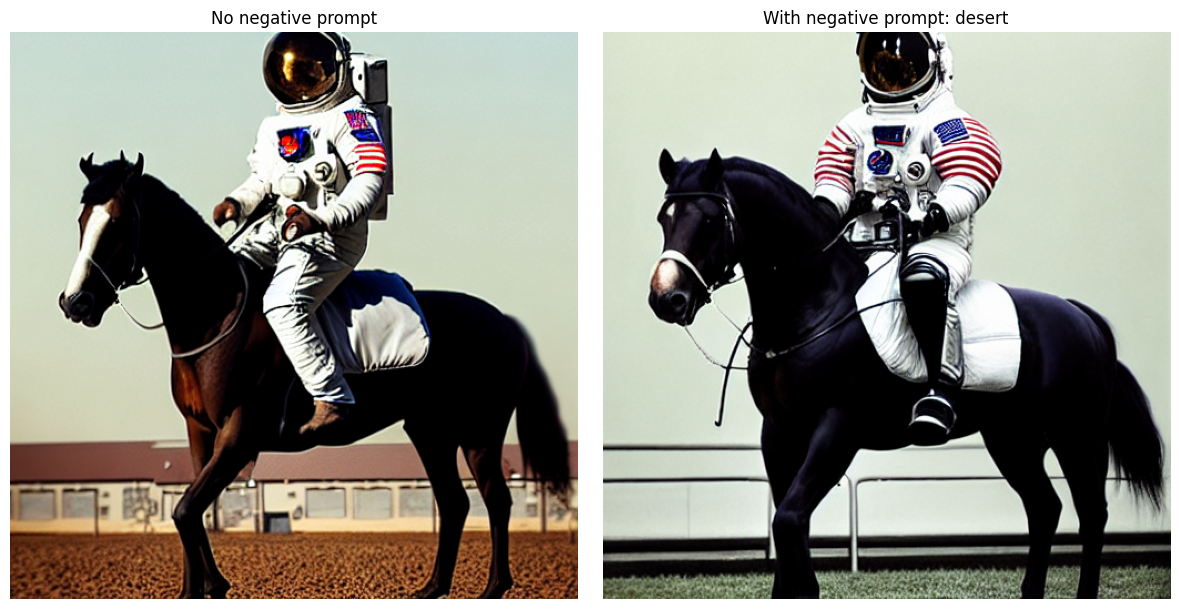

In [6]:
prompt = "a photograph of an astronaut riding a horse"
negative_prompt = "desert"
seed = 44

pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to("cuda")

# without a negative prompt
generator = torch.Generator("cuda").manual_seed(seed)
image_without_negative = pipe(prompt=prompt, guidance_scale=7.5, generator=generator).images[0]

# with the negative prompt
generator = torch.Generator("cuda").manual_seed(seed)
image_with_negative = pipe(prompt=prompt, negative_prompt=negative_prompt, guidance_scale=7.5, generator=generator).images[0]

fig, axes = plt.subplots(ncols=2, figsize=(12, 6))
axes[0].imshow(image_without_negative)
axes[0].set_title("No negative prompt")
axes[0].axis("off")

axes[1].imshow(image_with_negative)
axes[1].set_title("With negative prompt: desert")
axes[1].axis("off")

plt.tight_layout()
plt.show()

By adding “desert” to the negative prompt, the orange ground that could be interpreted as desert sand is removed, and the model replaces it with a grassy surface.